In [107]:
!pip install feature_engine catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.6 MB/s eta 0:00:00


In [212]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np


from feature_engine.selection import DropDuplicateFeatures, DropCorrelatedFeatures, DropFeatures, DropConstantFeatures
from feature_engine.transformation import BoxCoxTransformer, YeoJohnsonTransformer
from feature_engine.outliers import Winsorizer
from feature_engine.wrappers import SklearnTransformerWrapper
from feature_engine.encoding import RareLabelEncoder, OneHotEncoder


from catboost import CatBoostRegressor
import lightgbm as lgb
import optuna

In [4]:
df = pd.read_csv('offers_20250228_151130.csv')

# Analyz

In [6]:
df.head(5)

,id,floor,price,rooms_count,total_area,kitchen_area,year,parking,total_floors,lat,lng,balconiesCount,materialType
0,306295791,3,70000000,2,50.4,30.0,2021.0,ground,3,55.758103,37.636096,NaN,brick
1,310792515,4,82510000,2,111.5,35.8,2022.0,underground,8,55.752541,37.635727,0.0,monolithBrick
2,305062355,46,86000000,2,114.2,10.0,2012.0,NaN,75,55.750520,37.539401,NaN,monolith
3,293420284,6,20990000,1,36.1,9.0,1972.0,open,14,55.779347,37.611437,NaN,brick
4,314047060,53,125000000,2,144.8,50.0,2020.0,NaN,78,55.751584,37.535332,0.0,monolith


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              1500 non-null   int64  
 1   floor           1500 non-null   int64  
 2   price           1500 non-null   int64  
 3   rooms_count     1500 non-null   int64  
 4   total_area      1500 non-null   float64
 5   kitchen_area    1438 non-null   float64
 6   year            1132 non-null   float64
 7   parking         1008 non-null   object 
 8   total_floors    1500 non-null   int64  
 9   lat             1500 non-null   float64
 10  lng             1500 non-null   float64
 11  balconiesCount  978 non-null    float64
 12  materialType    1318 non-null   object 
dtypes: float64(6), int64(5), object(2)
memory usage: 152.5+ KB


In [7]:
df.describe()

,id,floor,price,rooms_count,total_area,kitchen_area,year,total_floors,lat,lng,balconiesCount
count,1.500000e+03,1500.000000,1.500000e+03,1500.000000,1500.000000,1438.000000,1132.000000,1500.000000,1500.000000,1500.000000,978.000000
mean,3.106547e+08,9.299333,3.355723e+07,1.668667,54.670813,12.110362,1999.605124,18.644667,55.729014,37.568851,0.366053
std,6.295511e+06,9.343158,3.958762e+07,0.470850,22.354137,7.158368,26.742418,13.980106,0.087737,0.125724,0.516813
min,2.019099e+08,1.000000,3.490000e+06,1.000000,13.200000,2.000000,1870.000000,3.000000,55.430998,36.865036,0.000000
25%,3.101708e+08,3.000000,1.295000e+07,1.000000,39.975000,7.500000,1974.000000,9.000000,55.686822,37.497130,0.000000
50%,3.126760e+08,6.000000,2.099000e+07,2.000000,48.900000,10.000000,2015.000000,14.000000,55.741196,37.569643,0.000000
75%,3.137320e+08,12.000000,3.800000e+07,2.000000,64.000000,15.000000,2022.000000,24.000000,55.780006,37.640749,1.000000
max,3.143047e+08,81.000000,6.300000e+08,2.000000,223.000000,80.000000,2027.000000,95.000000,56.010563,37.947263,3.000000


Пропуски в площади кухни и годом постройки дома можем заполнить модой. Пропуски в количсетве балкон изменить на 0. С типом дома и парковкой так не выйдет - введем Unknown.

In [9]:
def missings(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    missing_values = [float('nan'), '(none)']
    if 'balconiesCount' in data.columns:
        data['balconiesCount'] = data['balconiesCount'].fillna(0)
    if 'kitchen_area' in data.columns:
        data['kitchen_area'] = data['kitchen_area'].replace(missing_values, data.kitchen_area.mode()[0])

    if 'year' in data.columns:
        data['year'] = data['year'].replace(missing_values, data.year.mode()[0])

    return (data.fillna('Unknown'))

In [11]:
df = missings(df)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              1500 non-null   int64  
 1   floor           1500 non-null   int64  
 2   price           1500 non-null   int64  
 3   rooms_count     1500 non-null   int64  
 4   total_area      1500 non-null   float64
 5   kitchen_area    1500 non-null   float64
 6   year            1500 non-null   float64
 7   parking         1500 non-null   object 
 8   total_floors    1500 non-null   int64  
 9   lat             1500 non-null   float64
 10  lng             1500 non-null   float64
 11  balconiesCount  1500 non-null   float64
 12  materialType    1500 non-null   object 
dtypes: float64(6), int64(5), object(2)
memory usage: 152.5+ KB


По координатам квартиры найдем расстояние от центра города.

In [13]:
def haversine(lat, lon):
    R = 6371.0
    moscow_lat = 55.7558
    moscow_lng = 37.6173

    lat1_rad = np.radians(moscow_lat)
    lon1_rad = np.radians(moscow_lng)
    lat2_rad = np.radians(lat)
    lon2_rad = np.radians(lon)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    distance = R * c
    return distance

In [14]:
def calculate_distance(geo):
    return haversine(geo['lat'], geo['lng'])

In [15]:
df['distance_from_center'] = calculate_distance(df[['lat', 'lng']])

In [17]:
df.head(3)

,id,floor,price,rooms_count,total_area,kitchen_area,year,parking,total_floors,lat,lng,balconiesCount,materialType,distance_from_center
0,306295791,3,70000000,2,50.4,30.0,2021.0,ground,3,55.758103,37.636096,0.0,brick,1.203621
1,310792515,4,82510000,2,111.5,35.8,2022.0,underground,8,55.752541,37.635727,0.0,monolithBrick,1.208662
2,305062355,46,86000000,2,114.2,10.0,2012.0,Unknown,75,55.750520,37.539401,0.0,monolith,4.909835


# Visualization

Посмотрим на зависимости целовой переменной от других числовых столбцов. Для более корректного сравнения будем сравнивать не цену квартиры, а стоимость квадратного метра.

In [22]:
df['price_per_sqm'] = df['price']/df['total_area']

In [24]:
numeric_cols = ['floor', 'rooms_count', 'total_area', 'kitchen_area', 'year', 'total_floors', 'balconiesCount', 'distance_from_center']

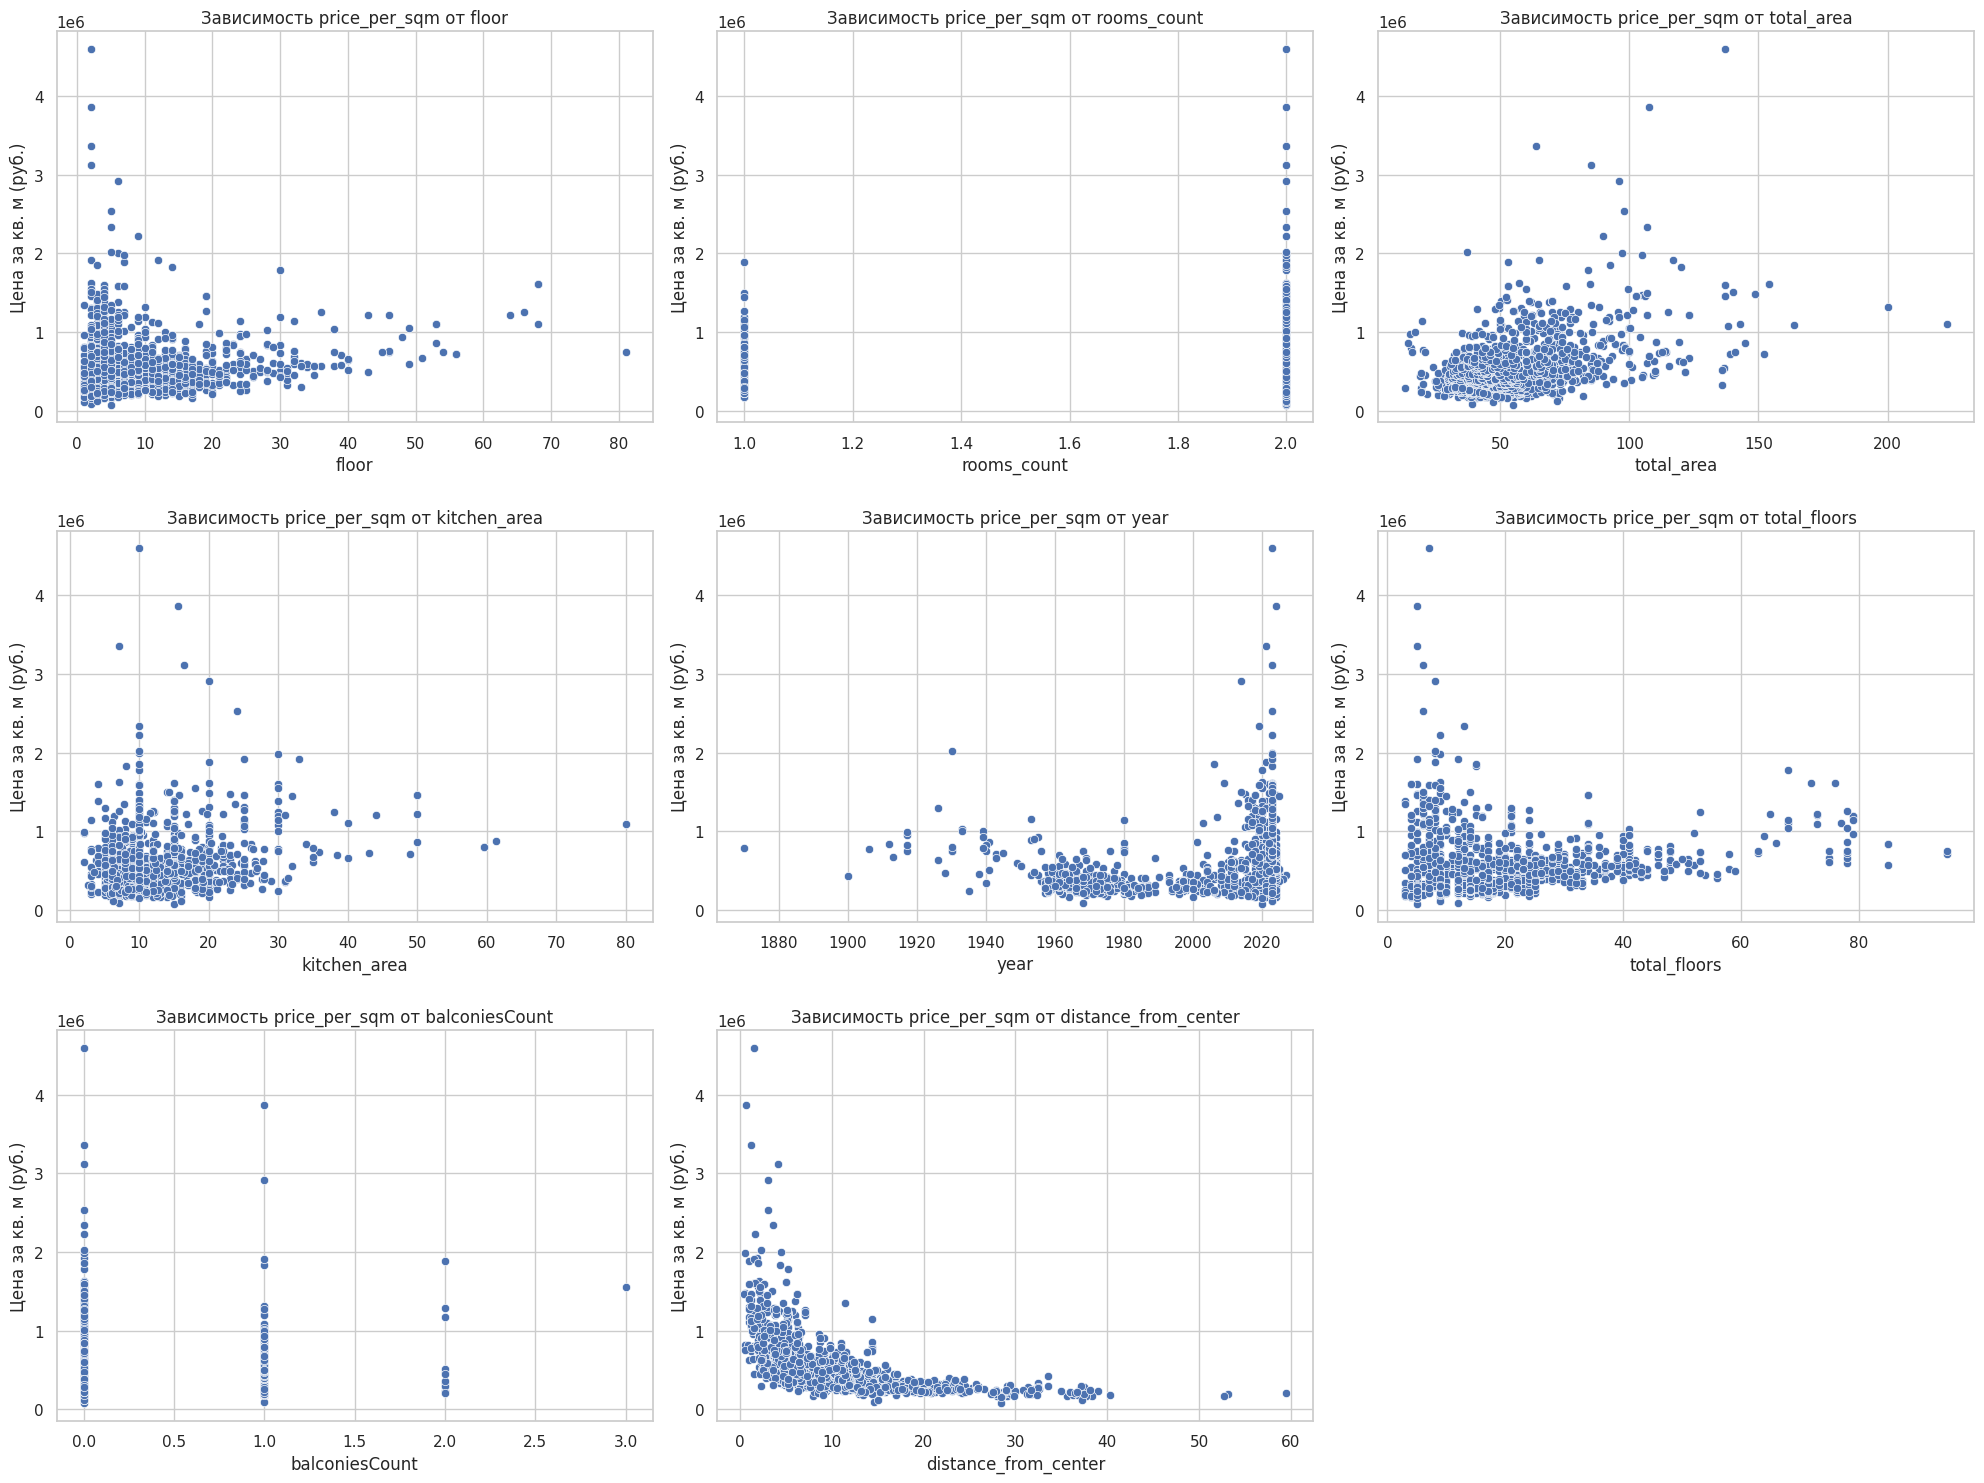

In [25]:
sns.set(style="whitegrid")
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)  # Устанавливаем 3 строки и 3 столбца для графиков
    sns.scatterplot(data=df, x=col, y='price_per_sqm', marker='o')
    plt.title(f'Зависимость price_per_sqm от {col}')
    plt.xlabel(col)
    plt.ylabel('Цена за кв. м (руб.)')

plt.tight_layout()
plt.show()

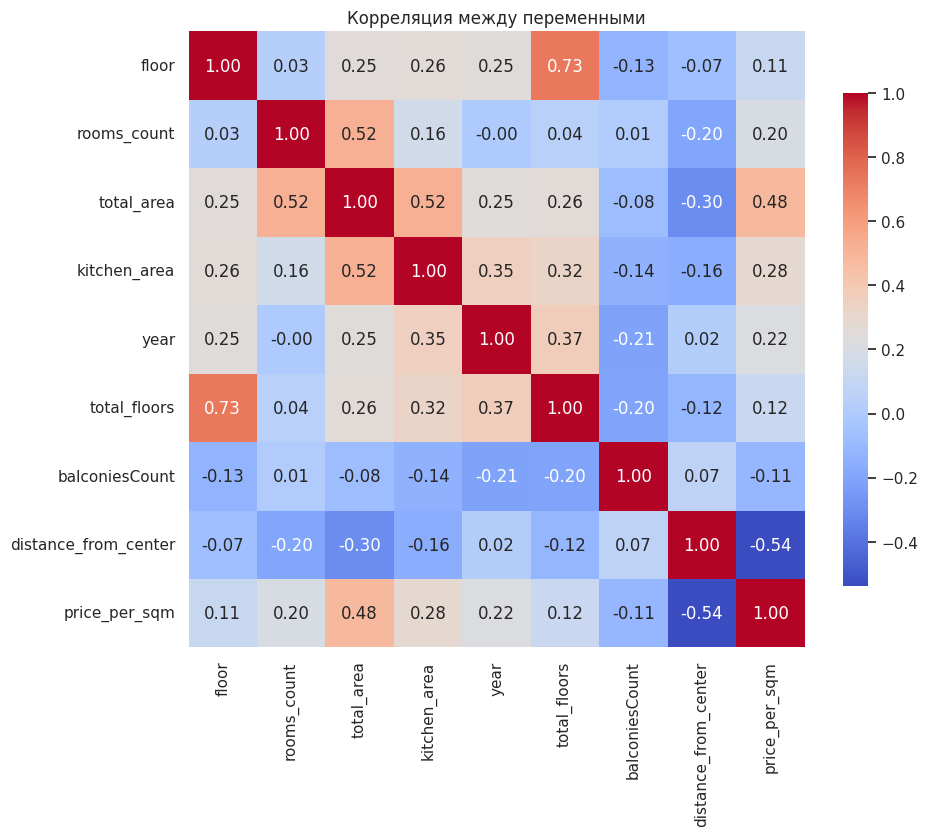

In [34]:
data = df[numeric_cols + ['price_per_sqm']]

correlation_matrix = data.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Корреляция между переменными')
plt.show()

In [36]:
df['materialType'].value_counts()

,count
materialType,
monolith,537
panel,315
brick,222
Unknown,182
monolithBrick,177
block,57
stalin,7
old,2
aerocreteBlock,1


In [37]:
df['parking'].value_counts()

,count
parking,
Unknown,492
underground,485
ground,422
open,74
multilevel,27


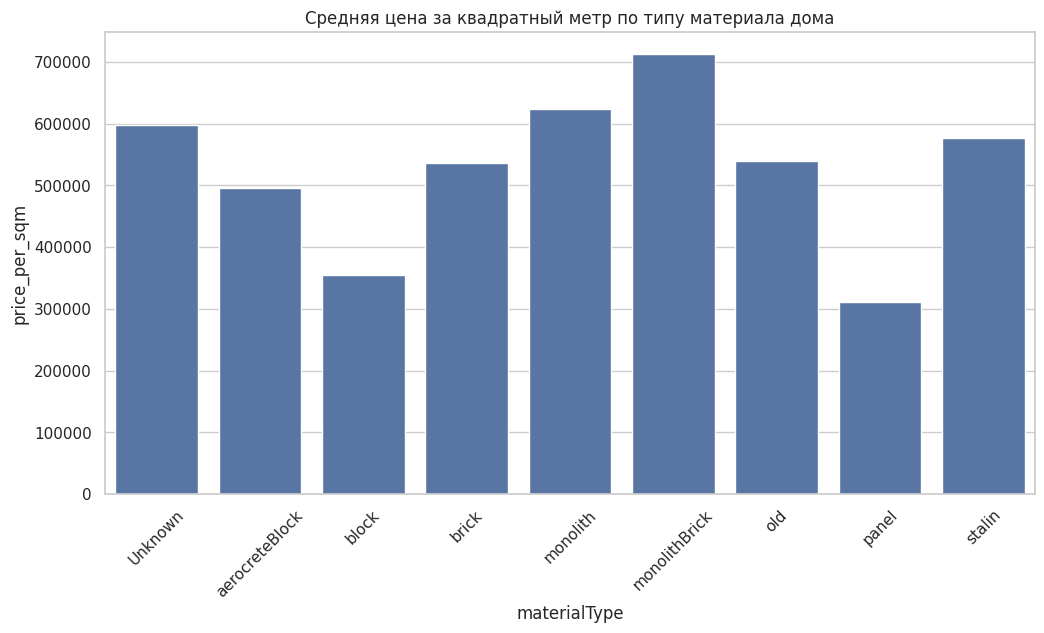

In [40]:
material_avg = df.groupby('materialType')['price_per_sqm'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='materialType', y='price_per_sqm', data=material_avg)
plt.title('Средняя цена за квадратный метр по типу материала дома')
plt.xticks(rotation=45)
plt.show()


In [43]:
df[df['materialType'] == 'Unknown'].describe()

,id,floor,price,rooms_count,total_area,kitchen_area,year,total_floors,lat,lng,balconiesCount,distance_from_center,price_per_sqm
count,1.820000e+02,182.000000,1.820000e+02,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,1.820000e+02
mean,3.109729e+08,11.043956,3.807288e+07,1.664835,56.764341,12.810440,2014.175824,21.758242,55.732505,37.550930,0.159341,10.140013,5.977181e+05
std,5.543657e+06,12.957570,3.875267e+07,0.473350,25.913331,8.271041,21.775141,17.677492,0.085346,0.106858,0.381760,7.453223,3.936709e+05
min,2.783058e+08,1.000000,4.300000e+06,1.000000,19.500000,2.000000,1912.000000,3.000000,55.433639,37.147789,0.000000,1.006870,7.846715e+04
25%,3.111948e+08,3.000000,1.386250e+07,1.000000,39.775000,8.350000,2020.000000,9.000000,55.701738,37.495132,0.000000,5.292075,3.195523e+05
50%,3.131445e+08,6.000000,2.400000e+07,2.000000,49.250000,10.000000,2023.000000,16.000000,55.746679,37.539240,0.000000,7.314633,5.012358e+05
75%,3.136605e+08,14.000000,4.947500e+07,2.000000,66.000000,15.675000,2023.000000,28.000000,55.778391,37.623099,0.000000,13.300146,7.540420e+05
max,3.142862e+08,81.000000,2.453000e+08,2.000000,223.000000,80.000000,2024.000000,95.000000,55.987341,37.805698,2.000000,40.259243,3.359375e+06


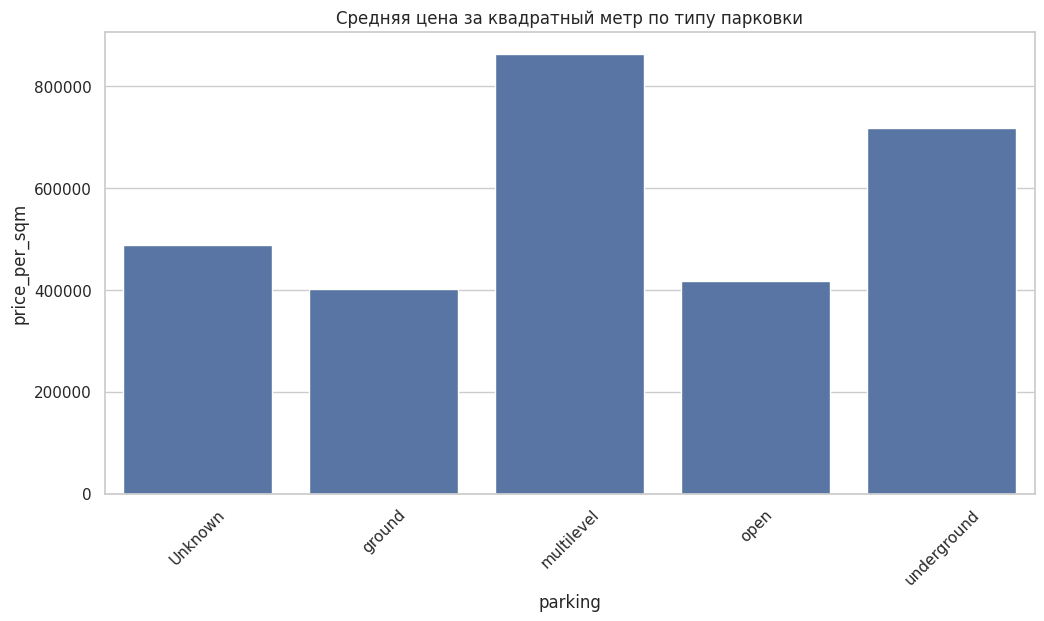

In [41]:
parking_avg = df.groupby('parking')['price_per_sqm'].mean().reset_index()

# Визуализация средних значений для parking
plt.figure(figsize=(12, 6))
sns.barplot(x='parking', y='price_per_sqm', data=parking_avg)
plt.title('Средняя цена за квадратный метр по типу парковки')
plt.xticks(rotation=45)
plt.show()

Как видно на графике, средняя цена дома при неуказанной парковке ближе к открытой или наземной, но в то же время немного выше. Оставим значение неизвестным.

In [44]:
def determine_floor_status(row):
    if row['floor'] == row['total_floors']:
        return 2
    elif row['floor'] == 1:
        return 1
    else:
        return 0

In [45]:
df['floor_status'] = df.apply(determine_floor_status, axis=1)

In [49]:
df['floor_status'] = df['floor_status'].astype('category')

Проверим, влияет ли первый/последний этаж на стоимость квартиры

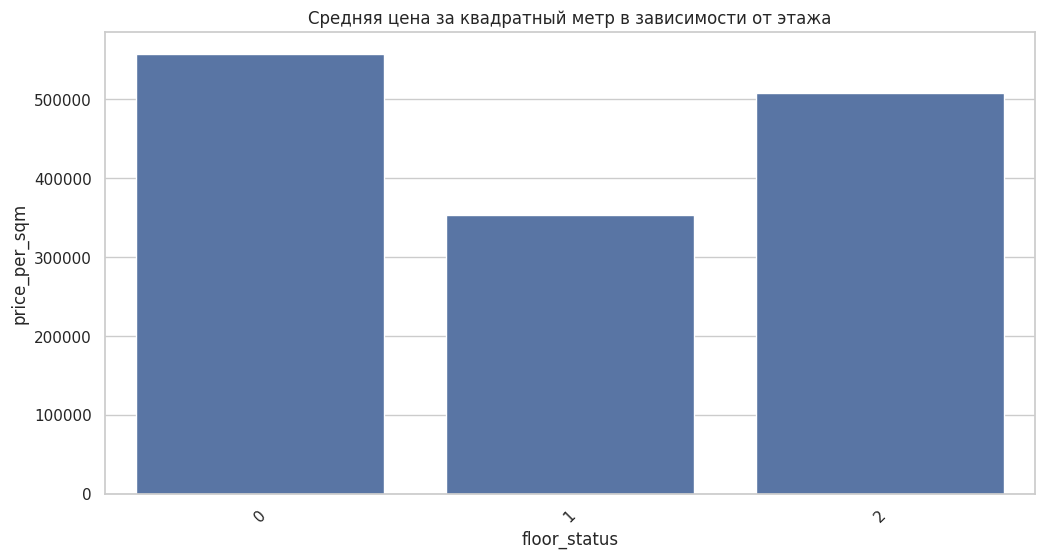

In [47]:
floor_avg = df.groupby('floor_status')['price_per_sqm'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='floor_status', y='price_per_sqm', data=floor_avg)
plt.title('Средняя цена за квадратный метр в зависимости от этажа')
plt.xticks(rotation=45)
plt.show()

# Preprocessing

In [119]:
df = pd.read_csv('offers_20250228_151130.csv')

In [120]:
def new_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    def haversine(lat, lon):
        R = 6371.0
        moscow_lat = 55.7558
        moscow_lng = 37.6173
        lat1_rad = np.radians(moscow_lat)
        lon1_rad = np.radians(moscow_lng)
        lat2_rad = np.radians(lat)
        lon2_rad = np.radians(lon)
        dlat = lat2_rad - lat1_rad
        dlon = lon2_rad - lon1_rad
        a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        distance = R * c
        return distance

    def determine_floor_status(row):
        if row['floor'] == row['total_floors']:
            return '2'
        elif row['floor'] == 1:
            return '1'
        else:
            return '0'

    if 'lat' in data.columns and 'lng' in data.columns:
        data['distance_from_center'] = data.apply(lambda row: haversine(row['lat'], row['lng']), axis=1)
    if 'floor' in data.columns and 'total_floors' in data.columns:
        data['floor_status'] = data.apply(determine_floor_status, axis=1)
    return data

In [121]:
preprocessor = Pipeline(steps=[
    ('imputer', FunctionTransformer(missings)),
    ('engineer', FunctionTransformer(new_features)),
    ('dropper', DropFeatures(['id','lat', 'lng'])),
    ('outliers', Winsorizer()),
    ('normalization', YeoJohnsonTransformer()),
    ('rare', RareLabelEncoder(tol = 0.005)),
    ('oneHotEncoder', OneHotEncoder(drop_last_binary=True))
])

In [122]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['price']), df['price'],
                                                                test_size=0.15, random_state=42)

In [123]:
print(f'Размер тренировочной выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер тренировочной выборки: (1275, 12)
Размер тестовой выборки: (225, 12)


In [124]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

/usr/local/lib/python3.11/dist-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable parking is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable materialType is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable floor_status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(


# Modeling

In [125]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## Lgbm

In [199]:
def objective(trial):

    # Определяем гиперпараметры
    params = {
        'objective': 'regression',
        'metric': 'mape',
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.1, 1.0), # 1.0
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.1, 1.0), # 1.0
        'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 1e-6, 10.0), # по вашим параметрам
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0), # Логарифмическое распределение
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0), # Логарифмическое распределение
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 300, 1300),
        'random_state': 42,
    }

    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    mape_scores = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train_preprocessed.iloc[train_index], X_train_preprocessed.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Обучение модели
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train_fold, y_train_fold)

        # Предсказания
        y_val_pred = model.predict(X_val_fold)

        # Оценка по метрике MAPE
        mape = mean_absolute_percentage_error(y_val_fold, y_val_pred)
        mape_scores.append(mape)

    # Возвращаем среднее значение MAPE
    return np.mean(mape_scores)


In [200]:
study = optuna.create_study(direction='minimize')  # Меньше MAPE — лучше
study.optimize(objective, n_trials=50)

[I 2025-03-03 14:15:09,149] A new study created in memory with name: no-name-9a4043a5-c19d-47ff-b305-b42aa3b113c1
<ipython-input-199-86ddca6a49ed>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0), # Логарифмическое распределение
<ipython-input-199-86ddca6a49ed>:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0), # Логарифмическое распределение
/usr/local/lib/python3.11/dist-packages/optuna/trial/_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "num_leaves"! This might be a configuration mistake. Optuna allow

In [201]:
best_params = study.best_params
print(f'Лучшие параметры: {best_params}')

Лучшие параметры: {'num_leaves': 225, 'feature_fraction': 0.8925926013055276, 'bagging_fraction': 0.4572990425422203, 'min_sum_hessian_in_leaf': 6.54402663971949, 'reg_alpha': 0.019523828745100568, 'reg_lambda': 0.6279411568257615, 'learning_rate': 0.048759639952718675}


In [219]:
lgbm_model = lgb.LGBMRegressor(**best_params)
lgbm_model.fit(X_train_preprocessed, y_train)

LGBMRegressor(bagging_fraction=0.4572990425422203,
              feature_fraction=0.8925926013055276,
              learning_rate=0.048759639952718675,
              min_sum_hessian_in_leaf=6.54402663971949, num_leaves=225,
              reg_alpha=0.019523828745100568, reg_lambda=0.6279411568257615)

In [220]:
lgbm_pred = lgbm_model.predict(X_test_preprocessed)

In [224]:
lgbm_mape = mean_absolute_percentage_error(y_test, lgbm_pred)
print(f'LightGBM MAPE: {lgbm_mape:.2f}')

LightGBM MAPE: 0.20


In [222]:
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
print(f'LightGBM MAPE: {lgbm_mae:.2f}')

LightGBM MAPE: 7220189.32


# Catboost

In [227]:
def objective(trial):

    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_seed': 42,
        'eval_metric': 'MAPE',
        'verbose': 0
    }

    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    mape_scores = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train_preprocessed.iloc[train_index], X_train_preprocessed.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model = CatBoostRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), verbose=0)

        y_val_pred = model.predict(X_val_fold)

        mape = mean_absolute_percentage_error(y_val_fold, y_val_pred)
        mape_scores.append(mape)

    return np.mean(mape_scores)

In [228]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
best_params = study.best_params
print(f'Лучшие параметры: {best_params}')
print('Best MAPE: ', study.best_value)

[I 2025-03-03 14:32:35,768] A new study created in memory with name: no-name-c5d5b7e9-f4f2-4907-8ebb-17d7e7ae7225
[I 2025-03-03 14:32:41,822] Trial 0 finished with value: 0.2234631882743071 and parameters: {'learning_rate': 0.15911340186312442, 'depth': 7, 'l2_leaf_reg': 3.188560203937229e-05, 'bagging_temperature': 0.30468176544408343}. Best is trial 0 with value: 0.2234631882743071.
[I 2025-03-03 14:32:44,393] Trial 1 finished with value: 0.22557786801302626 and parameters: {'learning_rate': 0.046058819370819515, 'depth': 5, 'l2_leaf_reg': 0.016297744103773673, 'bagging_temperature': 0.8263923015171294}. Best is trial 0 with value: 0.2234631882743071.
[I 2025-03-03 14:32:46,007] Trial 2 finished with value: 0.25573028597400604 and parameters: {'learning_rate': 0.24184346512567245, 'depth': 3, 'l2_leaf_reg': 3.262014319198762e-05, 'bagging_temperature': 0.8405078559301377}. Best is trial 0 with value: 0.2234631882743071.
[I 2025-03-03 14:33:02,704] Trial 3 finished with value: 0.22123

Best hyperparameters:  {'learning_rate': 0.0882820326309284, 'depth': 8, 'l2_leaf_reg': 3.3242906906860514e-06, 'bagging_temperature': 0.45176088869127495}
Best MAPE:  0.2125354746029881


In [238]:
catboost_model = CatBoostRegressor(**best_params)
catboost_model.fit(X_train_preprocessed, y_train)

0:	learn: 38587371.5131909	total: 2.37ms	remaining: 2.37s
1:	learn: 36126279.5637810	total: 4.71ms	remaining: 2.35s
2:	learn: 34063579.8406717	total: 7.76ms	remaining: 2.58s
3:	learn: 32450038.9282147	total: 9.86ms	remaining: 2.46s
4:	learn: 30974921.6197801	total: 11.9ms	remaining: 2.37s
5:	learn: 29688727.3732022	total: 13.9ms	remaining: 2.3s
6:	learn: 28345227.6761524	total: 15.8ms	remaining: 2.25s
7:	learn: 26632248.5595998	total: 17.9ms	remaining: 2.22s
8:	learn: 25256296.3389993	total: 19.9ms	remaining: 2.19s
9:	learn: 24292627.3639924	total: 21.9ms	remaining: 2.17s
10:	learn: 23508116.8143184	total: 22.8ms	remaining: 2.05s
11:	learn: 22490059.4048602	total: 24.9ms	remaining: 2.05s
12:	learn: 21352695.9618907	total: 27ms	remaining: 2.05s
13:	learn: 20208811.0472214	total: 28.9ms	remaining: 2.04s
14:	learn: 19734314.0594388	total: 29.7ms	remaining: 1.95s
15:	learn: 19005969.2867290	total: 31.6ms	remaining: 1.94s
16:	learn: 18289995.1194017	total: 33.7ms	remaining: 1.95s
17:	learn:

In [239]:
catboost_pred = catboost_model.predict(X_test_preprocessed)

In [242]:
catboost_mape = mean_absolute_percentage_error(y_test, catboost_pred)
print(f'catboost MAPE: {catboost_mape:.2f}')

catboost MAPE: 0.17


In [241]:
catboost_mae = mean_absolute_error(y_test, catboost_pred)
print(f'catboost MAE: {catboost_mae:.2f}')

catboost MAE: 5347786.65


Catboost лучше справляется с задачей. Возьмем его и будем подбирать гиперпараметры при каждом обновлении базы данных.